## Laptop Price Prediction

### Step 01: Importing Packages

In [1]:
import numpy as np
import pandas as pd

### Step 02: Importing CSV file

In [3]:

df=pd.read_csv("laptop_price.csv",encoding="latin1")
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


### Since the Price is in euros, Lets convert it into the NPR first.

In [4]:
converion_rate=133 # 1 euro = 133 NPR so
df['Price_NPR']=df['Price_euros']*converion_rate

# Since, we have already added Price_NPR columns. So, lets drop the Price_euros column.
df.drop(columns=['Price_euros'], inplace=True)

df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_NPR
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,178178.77
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,119559.02
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,76475.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,337480.85
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,239878.80


In [5]:
# Checking the total rows and columsn in a dataset
df.shape

(1303, 13)

In [6]:
# Information of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   Product           1303 non-null   object 
 3   TypeName          1303 non-null   object 
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   object 
 6   Cpu               1303 non-null   object 
 7   Ram               1303 non-null   object 
 8   Memory            1303 non-null   object 
 9   Gpu               1303 non-null   object 
 10  OpSys             1303 non-null   object 
 11  Weight            1303 non-null   object 
 12  Price_NPR         1303 non-null   float64
dtypes: float64(2), int64(1), object(10)
memory usage: 132.5+ KB


### Step 3: Data Preprocessing 

In [7]:
# Checking the duplicate rows
df.duplicated().sum()

np.int64(0)

In [8]:
# Checking if there is any missing value or not
df.isnull().sum()

laptop_ID           0
Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price_NPR           0
dtype: int64

In [10]:
# Since the RAM and Weight are string so we need to change these to integer.
# It is because model cannot process strings directly.
# We need to extract the numeric value and convert it to integer /float so the model can learn properly.

df['Ram']=df['Ram'].str.replace("GB","").astype(int)
df['Weight']=df['Weight'].str.replace("kg","").astype(float)
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_NPR
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,178178.77
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,119559.02
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,76475.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,337480.85
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,239878.80


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   Product           1303 non-null   object 
 3   TypeName          1303 non-null   object 
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   object 
 6   Cpu               1303 non-null   object 
 7   Ram               1303 non-null   int64  
 8   Memory            1303 non-null   object 
 9   Gpu               1303 non-null   object 
 10  OpSys             1303 non-null   object 
 11  Weight            1303 non-null   float64
 12  Price_NPR         1303 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 132.5+ KB


### Step 4: EDA(Exploratory Data Analysis)

In [12]:
import seaborn as sns
from matplotlib import pyplot as plt

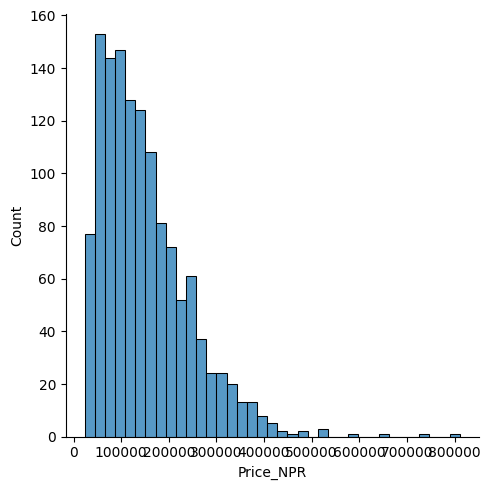

In [14]:
sns.displot(df['Price_NPR'])


### Which company laptop has the highest sale in terms of affordability?

<Axes: title={'center': "Laptop Company's Name "}, xlabel='Company'>

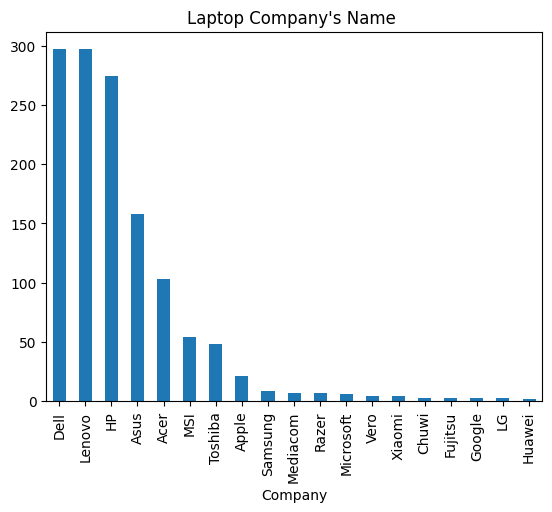

In [15]:
plt.title("Laptop Company's Name ")
df['Company'].value_counts().plot(kind='bar')

### Which company is expensive in terms of Price

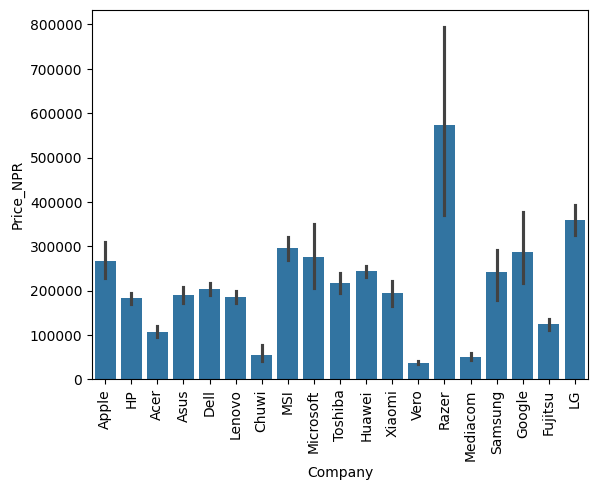

In [10]:
sns.barplot(x=df['Company'],y=df['Price_NPR'])
plt.xticks(rotation='vertical')
plt.show()

## Step 04: EDA (Exploratory Data Analysis) + Feature Engineering

Since machine learning models only understand numeric values,
we need to convert categorical columns into numeric form.

### Company Column
We have already visualized the Company column with Price.
Now we will apply get_dummies to convert it into numeric values
and drop the original Company column.

In [16]:
df=df.join(pd.get_dummies(df.Company))
df=df.drop("Company",axis=1)

In [17]:
# Since the Companies are in true and false , so lets make it in numeric form 
df = df.apply(lambda x: x.astype(int) if x.dtype == bool else x)

In [18]:

df.head()



,laptop_ID,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,...,LG,Lenovo,MSI,Mediacom,Microsoft,Razer,Samsung,Toshiba,Vero,Xiaomi
0,1,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,...,0,0,0,0,0,0,0,0,0,0
1,2,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,...,0,0,0,0,0,0,0,0,0,0
2,3,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,...,0,0,0,0,0,0,0,0,0,0
3,4,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,...,0,0,0,0,0,0,0,0,0,0
4,5,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Since Product column contains individual laptop model names
# with too many unique values, it is not useful for price prediction
# Therefore we should drop it

df = df.drop(['Product'], axis=1)
df.head()

,laptop_ID,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,...,LG,Lenovo,MSI,Mediacom,Microsoft,Razer,Samsung,Toshiba,Vero,Xiaomi
0,1,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,...,0,0,0,0,0,0,0,0,0,0
1,2,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,...,0,0,0,0,0,0,0,0,0,0
2,3,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,...,0,0,0,0,0,0,0,0,0,0
3,4,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,...,0,0,0,0,0,0,0,0,0,0
4,5,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,...,0,0,0,0,0,0,0,0,0,0


### TypeName

<Axes: title={'center': 'Types of Laptop'}, xlabel='TypeName'>

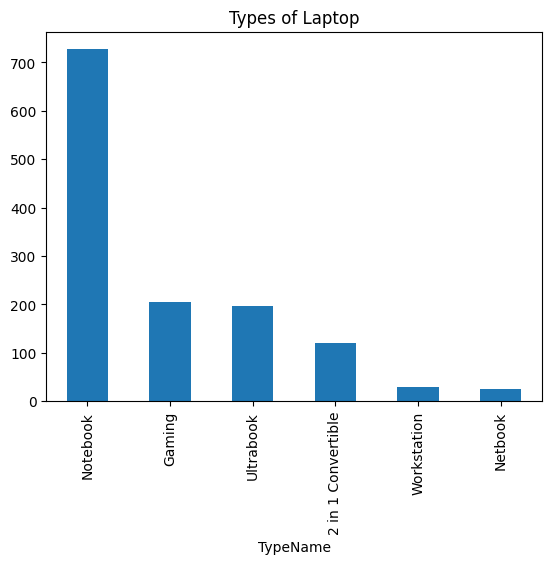

In [ ]:

plt.title("Types of Laptop")
df['TypeName'].value_counts().plot(kind='bar')


### TypeName vs Price

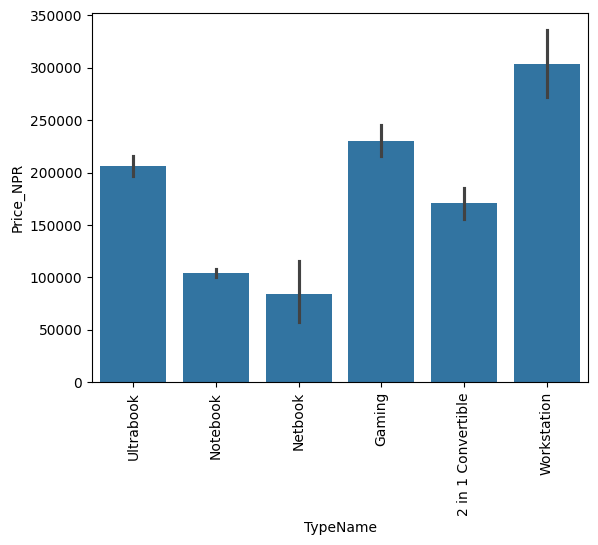

In [21]:
sns.barplot(x=df['TypeName'],y=df['Price_NPR'])
plt.xticks(rotation='vertical')
plt.show()

#### Since machine learning models require numerical input, the categorical feature TypeName will be now converted into numerical format using One-Hot Encoding, creating dummy variables for each category.

In [22]:
df=df.join(pd.get_dummies(df.TypeName))
df=df.drop("TypeName",axis=1)

In [23]:
# Since the TypeName are in true and false , so lets make it in numeric form 
df = df.apply(lambda x: x.astype(int) if x.dtype == bool else x)

In [24]:
df.head()

,laptop_ID,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_NPR,...,Samsung,Toshiba,Vero,Xiaomi,2 in 1 Convertible,Gaming,Netbook,Notebook,Ultrabook,Workstation
0,1,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,178178.77,...,0,0,0,0,0,0,0,0,1,0
1,2,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,119559.02,...,0,0,0,0,0,0,0,0,1,0
2,3,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,76475.00,...,0,0,0,0,0,0,0,1,0,0
3,4,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,337480.85,...,0,0,0,0,0,0,0,0,1,0
4,5,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,239878.80,...,0,0,0,0,0,0,0,0,1,0


### Inches

<Axes: title={'center': 'Inches'}, xlabel='Inches'>

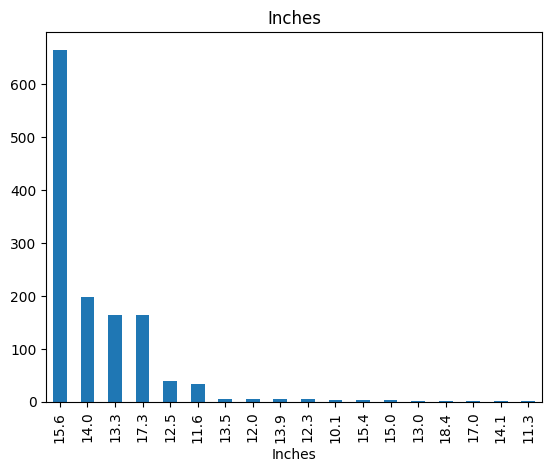

In [25]:

plt.title("Inches")
df['Inches'].value_counts().plot(kind='bar')

### Inches vs Price

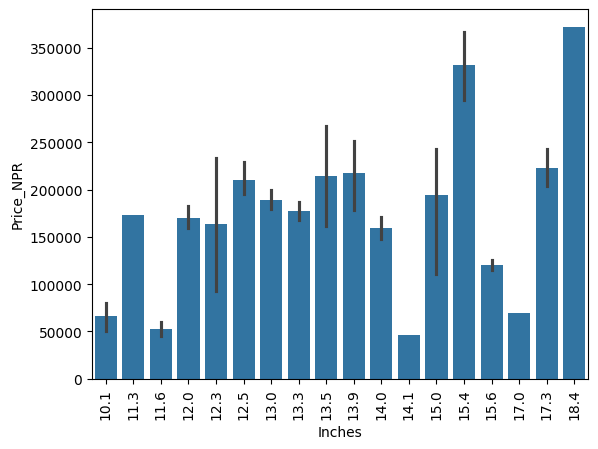

In [26]:

sns.barplot(x=df['Inches'],y=df['Price_NPR'])
plt.xticks(rotation="vertical")
plt.show()

### Screen Resolution

In [27]:
df['ScreenResolution'].value_counts()

ScreenResolution
Full HD 1920x1080                                507
1366x768                                         281
IPS Panel Full HD 1920x1080                      230
IPS Panel Full HD / Touchscreen 1920x1080         53
Full HD / Touchscreen 1920x1080                   47
1600x900                                          23
Touchscreen 1366x768                              16
Quad HD+ / Touchscreen 3200x1800                  15
IPS Panel 4K Ultra HD 3840x2160                   12
IPS Panel 4K Ultra HD / Touchscreen 3840x2160     11
4K Ultra HD / Touchscreen 3840x2160               10
IPS Panel 1366x768                                 7
Touchscreen 2560x1440                              7
4K Ultra HD 3840x2160                              7
IPS Panel Retina Display 2304x1440                 6
IPS Panel Retina Display 2560x1600                 6
Touchscreen 2256x1504                              6
IPS Panel Quad HD+ / Touchscreen 3200x1800         6
IPS Panel Touchscreen 2560x14

<Axes: xlabel='ScreenResolution'>

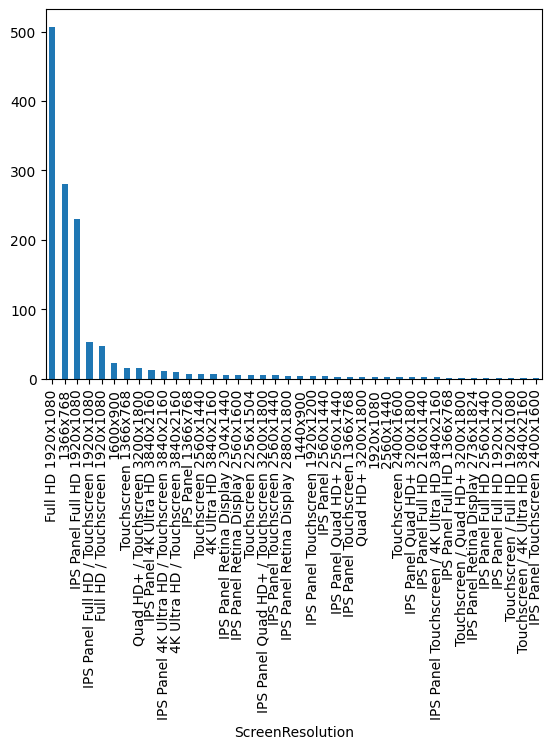

In [28]:
df.ScreenResolution.value_counts().plot(kind='bar')

### Perfoming Feature Engineering of ScreenResolution.

### 1) Touchscreen

In [29]:
df['Touchscreen'] = df['ScreenResolution'].apply(lambda x: 1 if 'Touchscreen' in x else 0)
df.head()
df.sample(5)


,laptop_ID,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_NPR,...,Toshiba,Vero,Xiaomi,2 in 1 Convertible,Gaming,Netbook,Notebook,Ultrabook,Workstation,Touchscreen
37,38,17.3,IPS Panel Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8,128GB SSD + 1TB HDD,AMD Radeon 530,Windows 10,2.80,130207.00,...,0,0,0,0,0,0,1,0,0,0
551,558,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,Windows 10,1.90,148559.67,...,0,0,0,0,0,0,1,0,0,0
401,408,17.3,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1050,Windows 10,2.90,203357.00,...,0,0,0,0,1,0,0,0,0,0
212,217,15.6,Full HD 1920x1080,Intel Core i3 6006U 2GHz,4,500GB HDD,Intel HD Graphics 520,No OS,2.10,46417.00,...,0,0,0,0,0,0,1,0,0,0
505,512,13.3,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,Windows 10,1.44,126217.00,...,0,0,0,0,0,0,1,0,0,0


<Axes: xlabel='Touchscreen'>

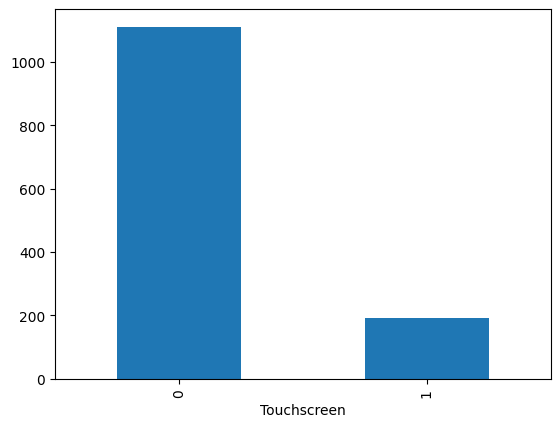

In [30]:
df['Touchscreen'].value_counts().plot(kind='bar')

### TouchScreen vs Price

<Axes: xlabel='Touchscreen', ylabel='Price_NPR'>

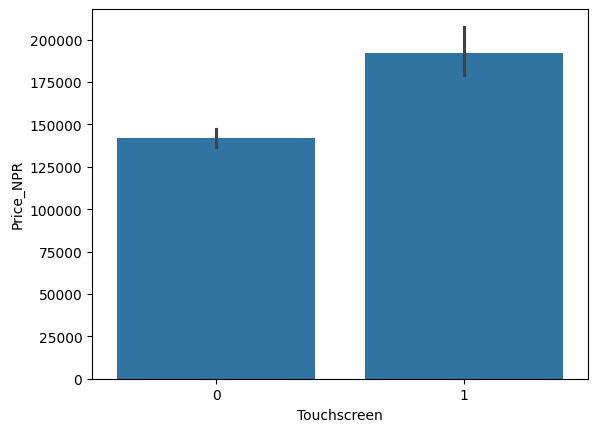

In [31]:
sns.barplot(x=df['Touchscreen'],y=df['Price_NPR'])

### 2) IPS Panel

In [32]:
df['IPS']=df['ScreenResolution'].apply(lambda x:1 if 'IPS' in x else 0)
df.head()
df.sample(4)

,laptop_ID,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_NPR,...,Vero,Xiaomi,2 in 1 Convertible,Gaming,Netbook,Notebook,Ultrabook,Workstation,Touchscreen,IPS
834,843,14.0,IPS Panel Full HD 1920x1080,Intel Core i5 7300U 2.6GHz,8,256GB SSD,Intel HD Graphics 620,Windows 10,1.32,219450.0,...,0,0,0,0,0,1,0,0,0,1
557,564,17.3,1600x900,Intel Core i7 7500U 2.7GHz,6,128GB SSD + 1TB HDD,Nvidia GeForce 940MX,Windows 10,2.80,126217.0,...,0,0,0,0,0,1,0,0,0,0
1172,1190,15.6,1366x768,Intel Celeron Dual Core N3050 1.6GHz,4,500GB HDD,Intel HD Graphics,Windows 10,2.20,49077.0,...,0,0,0,0,0,1,0,0,0,0
351,357,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,8,256GB SSD,Intel HD Graphics 620,Windows 10,1.84,173432.0,...,0,0,0,0,0,1,0,0,0,0


<Axes: xlabel='IPS'>

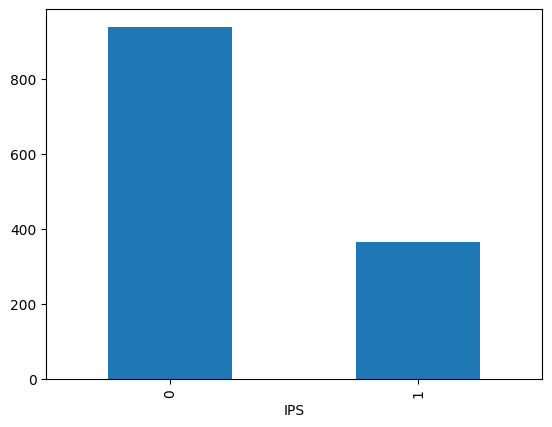

In [33]:
df['IPS'].value_counts().plot(kind='bar')

### IPS Panel Vs Price

<Axes: xlabel='IPS', ylabel='Price_NPR'>

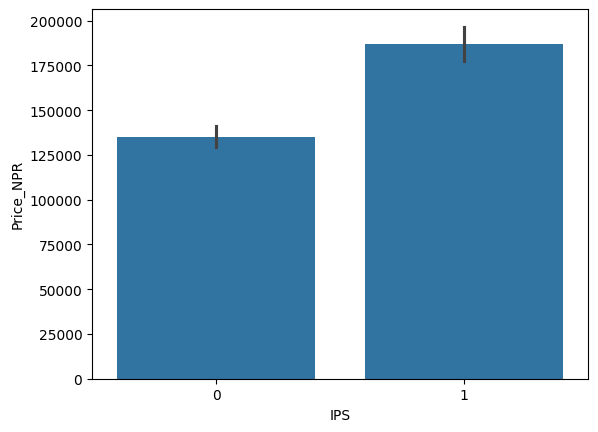

In [34]:
sns.barplot(x=df['IPS'],y=df['Price_NPR'])

### 3) Resolution

In [35]:
# Now the turn of resolution ie.e  screen width and height

df['ScreenResolution']=df.ScreenResolution.str.split(" ").apply(lambda x:x[-1])
df['sc_width']=df.ScreenResolution.str.split("x").apply(lambda x:x[0]).astype(int)
df['sc_height']=df.ScreenResolution.str.split("x").apply(lambda x:x[1]).astype(int)
df.head()


,laptop_ID,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_NPR,...,2 in 1 Convertible,Gaming,Netbook,Notebook,Ultrabook,Workstation,Touchscreen,IPS,sc_width,sc_height
0,1,13.3,2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,178178.77,...,0,0,0,0,1,0,0,1,2560,1600
1,2,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,119559.02,...,0,0,0,0,1,0,0,0,1440,900
2,3,15.6,1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,76475.00,...,0,0,0,1,0,0,0,0,1920,1080
3,4,15.4,2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,337480.85,...,0,0,0,0,1,0,0,1,2880,1800
4,5,13.3,2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,239878.80,...,0,0,0,0,1,0,0,1,2560,1600


In [36]:

df.drop(['ScreenResolution'], axis=1, inplace=True)
df.shape

(1303, 38)

#### Calculating the PPi using sc_width, sc_height, and Inches then dropping sc_width, sc_height, and Inches since they're no longer needed.

In [37]:
df['PPI'] = (((df['sc_width']**2) + (df['sc_height']**2))**0.5) / df['Inches']

In [38]:
df.drop(columns=['sc_width', 'sc_height', 'Inches'], inplace=True)

<Axes: xlabel='PPI'>

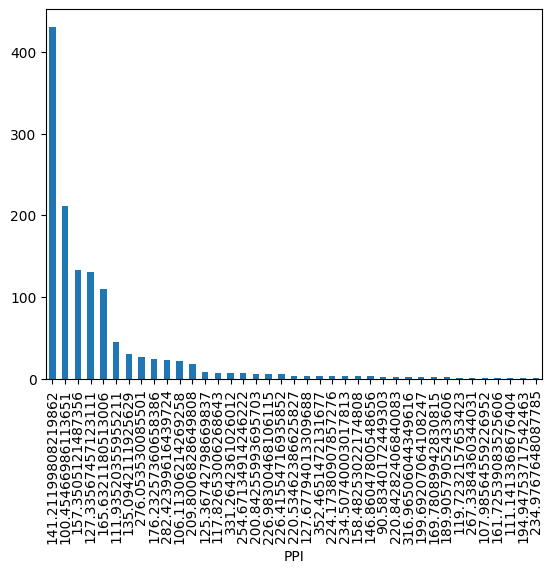

In [39]:
df.PPI.value_counts().plot(kind='bar')

In [40]:
df.head()

,laptop_ID,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_NPR,Acer,Apple,...,Xiaomi,2 in 1 Convertible,Gaming,Netbook,Notebook,Ultrabook,Workstation,Touchscreen,IPS,PPI
0,1,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,178178.77,0,1,...,0,0,0,0,0,1,0,0,1,226.983005
1,2,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,119559.02,0,1,...,0,0,0,0,0,1,0,0,0,127.677940
2,3,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,76475.00,0,0,...,0,0,0,0,1,0,0,0,0,141.211998
3,4,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,337480.85,0,1,...,0,0,0,0,0,1,0,0,1,220.534624
4,5,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,239878.80,0,1,...,0,0,0,0,0,1,0,0,1,226.983005


In [41]:
df.Cpu.value_counts()

Cpu
Intel Core i5 7200U 2.5GHz       190
Intel Core i7 7700HQ 2.8GHz      146
Intel Core i7 7500U 2.7GHz       134
Intel Core i7 8550U 1.8GHz        73
Intel Core i5 8250U 1.6GHz        72
                                ... 
Intel Core i5 7200U 2.70GHz        1
Intel Core M M7-6Y75 1.2GHz        1
Intel Core M 6Y54 1.1GHz           1
AMD E-Series 9000 2.2GHz           1
Samsung Cortex A72&A53 2.0GHz      1
Name: count, Length: 118, dtype: int64

In [42]:
def fetch(text):
    if 'Intel Core i7' in text:
        return 'Intel Core i7'
    elif 'Intel Core i5' in text:
        return 'Intel Core i5'
    elif 'Intel Core i3' in text:
        return 'Intel Core i3'
    else:
        if text.split()[0] == 'Intel':
            return 'Other Intel Processor'
        elif text.split()[0] == 'AMD':
            return 'AMD Processor'
        else:
            return 'Other'

df['CPU_Brand'] = df['Cpu'].apply(fetch)

# Verify
print(df['CPU_Brand'].value_counts())


CPU_Brand
Intel Core i7            527
Intel Core i5            423
Other Intel Processor    154
Intel Core i3            136
AMD Processor             62
Other                      1
Name: count, dtype: int64


In [43]:
df['CPU_Brand'] = df['Cpu'].apply(fetch)
df['CPU_Frequency'] = df['Cpu'].str.split(" ").apply(lambda x: x[-1])

In [44]:
df.drop(['Cpu'], axis=1, inplace=True)

In [45]:
df.head()

,laptop_ID,Ram,Memory,Gpu,OpSys,Weight,Price_NPR,Acer,Apple,Asus,...,Gaming,Netbook,Notebook,Ultrabook,Workstation,Touchscreen,IPS,PPI,CPU_Brand,CPU_Frequency
0,1,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,178178.77,0,1,0,...,0,0,0,1,0,0,1,226.983005,Intel Core i5,2.3GHz
1,2,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,119559.02,0,1,0,...,0,0,0,1,0,0,0,127.677940,Intel Core i5,1.8GHz
2,3,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,76475.00,0,0,0,...,0,0,1,0,0,0,0,141.211998,Intel Core i5,2.5GHz
3,4,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,337480.85,0,1,0,...,0,0,0,1,0,0,1,220.534624,Intel Core i7,2.7GHz
4,5,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,239878.80,0,1,0,...,0,0,0,1,0,0,1,226.983005,Intel Core i5,3.1GHz


<Axes: xlabel='CPU_Brand'>

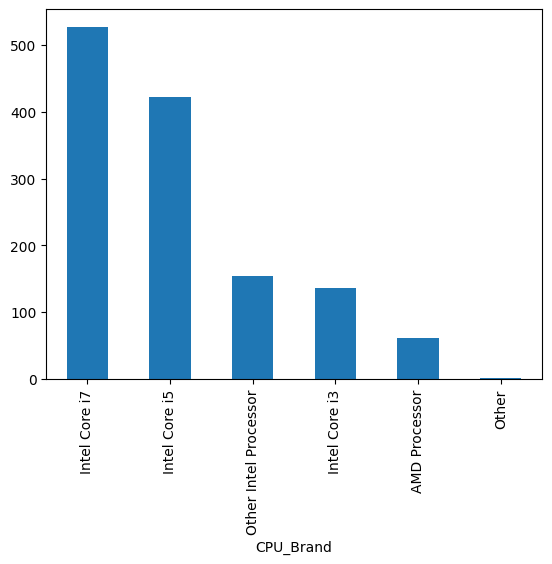

In [46]:
df.CPU_Brand.value_counts().plot(kind='bar')

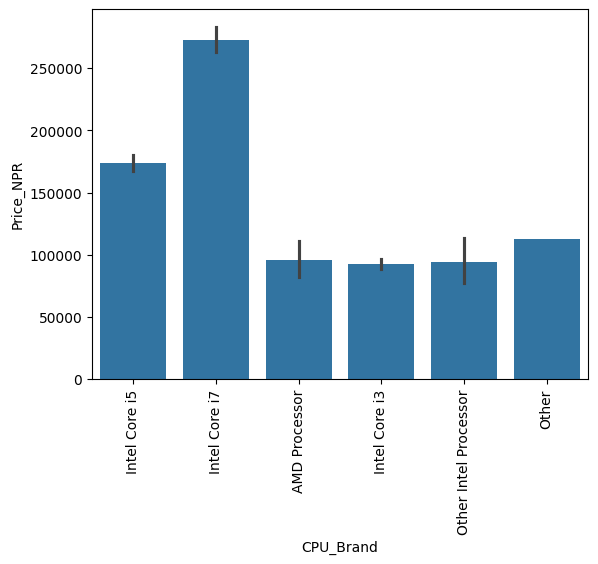

In [45]:
sns.barplot(x=df['CPU_Brand'],y=df['Price_NPR'])
plt.xticks(rotation='vertical')
plt.show()

In [47]:
df['CPU_Frequency'] = df['CPU_Frequency'].str.replace('GHz', '').astype(float)

In [48]:
df.head()

,laptop_ID,Ram,Memory,Gpu,OpSys,Weight,Price_NPR,Acer,Apple,Asus,...,Gaming,Netbook,Notebook,Ultrabook,Workstation,Touchscreen,IPS,PPI,CPU_Brand,CPU_Frequency
0,1,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,178178.77,0,1,0,...,0,0,0,1,0,0,1,226.983005,Intel Core i5,2.3
1,2,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,119559.02,0,1,0,...,0,0,0,1,0,0,0,127.677940,Intel Core i5,1.8
2,3,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,76475.00,0,0,0,...,0,0,1,0,0,0,0,141.211998,Intel Core i5,2.5
3,4,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,337480.85,0,1,0,...,0,0,0,1,0,0,1,220.534624,Intel Core i7,2.7
4,5,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,239878.80,0,1,0,...,0,0,0,1,0,0,1,226.983005,Intel Core i5,3.1


### CPU Frequency

In [49]:
df.CPU_Frequency.dtype

dtype('float64')

<Axes: xlabel='CPU_Frequency'>

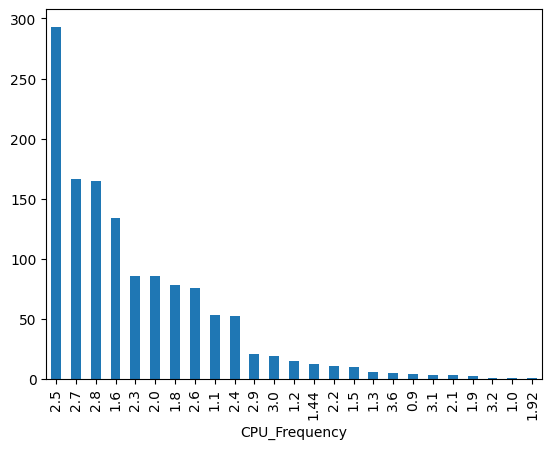

In [50]:
df.CPU_Frequency.value_counts().plot(kind='bar')

### CPU frequency vs Price

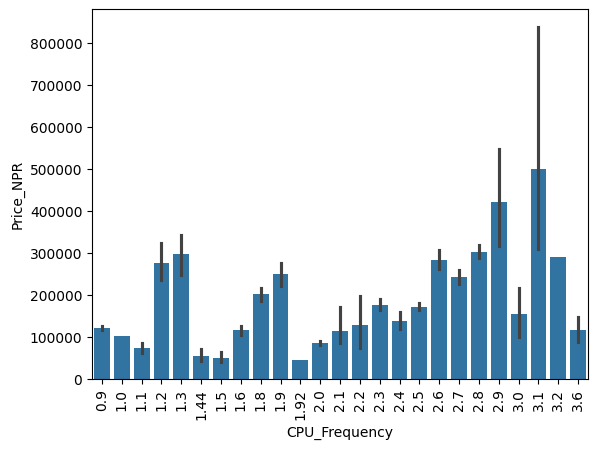

In [50]:
sns.barplot(x=df['CPU_Frequency'],y=df['Price_NPR'])
plt.xticks(rotation='vertical')
plt.show()

### Memory

<Axes: xlabel='Memory'>

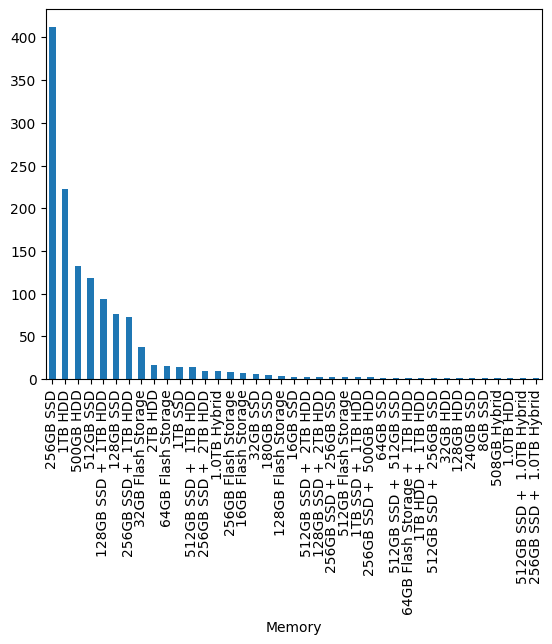

In [51]:
df.Memory.value_counts().plot(kind='bar')

### Memory vs Price

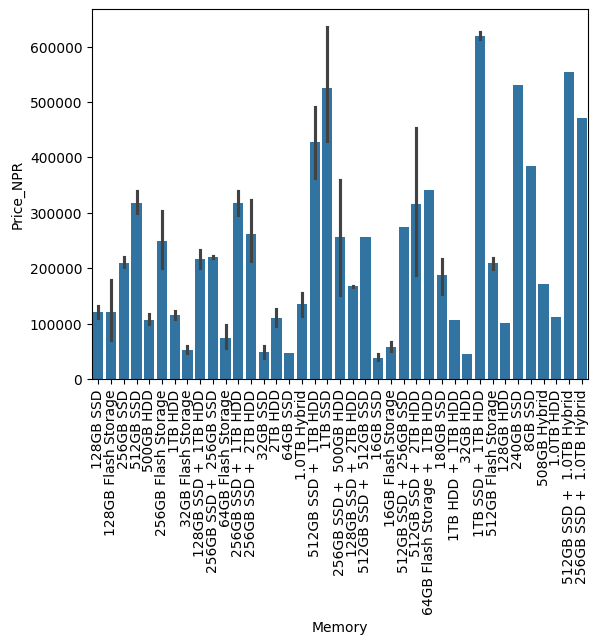

In [52]:
sns.barplot(x=df['Memory'],y=df['Price_NPR'])
plt.xticks(rotation='vertical')
plt.show()

##### Since the Memory column contained multiple unique formats, it will be processed by extracting common memory types such as SSD, HDD, Flash Storage, and Hybrid into separate binary columns. Additionally, the total memory size will also be extracted and converted into a numerical feature (Memory_Size) for model compatibility

In [51]:
df['Memory_Size'] = df['Memory'].str.extract(r'(\d+)').astype(int)
df['Memory_Unit'] = df['Memory'].str.extract(r'(GB|TB)')
df['Memory_Size'] = df.apply(
    lambda x: x['Memory_Size'] * 1000 if x['Memory_Unit'] == 'TB' else x['Memory_Size'], axis=1)
df.drop(columns=['Memory_Unit'], inplace=True)

In [52]:
df['SSD'] = df['Memory'].apply(lambda x: 1 if 'SSD' in x else 0)
df['HDD'] = df['Memory'].apply(lambda x: 1 if 'HDD' in x else 0)
df['Flash_Storage'] = df['Memory'].apply(lambda x: 1 if 'Flash Storage' in x else 0)
df['Hybrid'] = df['Memory'].apply(lambda x: 1 if 'Hybrid' in x else 0)

In [53]:
df.drop(columns=['Memory'], inplace=True)

In [54]:
df.head()

,laptop_ID,Ram,Gpu,OpSys,Weight,Price_NPR,Acer,Apple,Asus,Chuwi,...,Touchscreen,IPS,PPI,CPU_Brand,CPU_Frequency,Memory_Size,SSD,HDD,Flash_Storage,Hybrid
0,1,8,Intel Iris Plus Graphics 640,macOS,1.37,178178.77,0,1,0,0,...,0,1,226.983005,Intel Core i5,2.3,128,1,0,0,0
1,2,8,Intel HD Graphics 6000,macOS,1.34,119559.02,0,1,0,0,...,0,0,127.677940,Intel Core i5,1.8,128,0,0,1,0
2,3,8,Intel HD Graphics 620,No OS,1.86,76475.00,0,0,0,0,...,0,0,141.211998,Intel Core i5,2.5,256,1,0,0,0
3,4,16,AMD Radeon Pro 455,macOS,1.83,337480.85,0,1,0,0,...,0,1,220.534624,Intel Core i7,2.7,512,1,0,0,0
4,5,8,Intel Iris Plus Graphics 650,macOS,1.37,239878.80,0,1,0,0,...,0,1,226.983005,Intel Core i5,3.1,256,1,0,0,0


### GPU

In [55]:
df['Gpu_Brand'] = df['Gpu'].apply(lambda x: x.split()[0])

<Axes: xlabel='Gpu_Brand'>

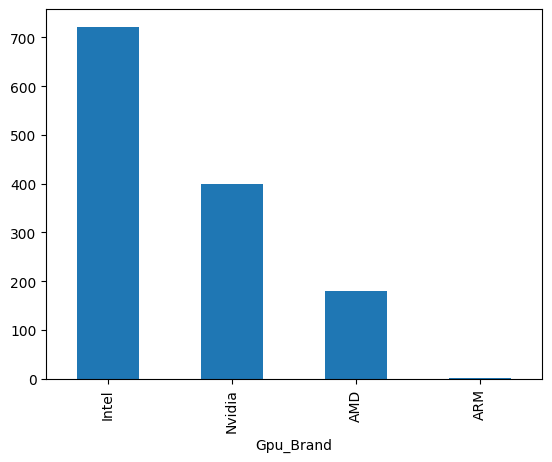

In [56]:
df.Gpu_Brand.value_counts().plot(kind= 'bar')

### Gpu_Brand vs Price

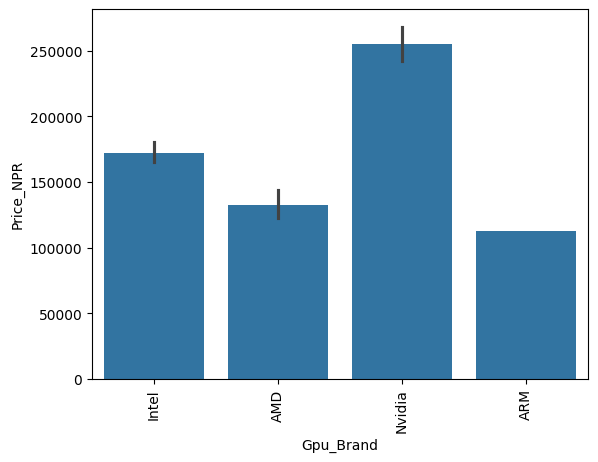

In [59]:
sns.barplot(x=df['Gpu_Brand'],y=df['Price_NPR'])
plt.xticks(rotation='vertical')
plt.show()

### Dropping the Original GPU column

In [57]:
df.drop(columns=['Gpu'], inplace=True)

In [58]:
df.head()

,laptop_ID,Ram,OpSys,Weight,Price_NPR,Acer,Apple,Asus,Chuwi,Dell,...,IPS,PPI,CPU_Brand,CPU_Frequency,Memory_Size,SSD,HDD,Flash_Storage,Hybrid,Gpu_Brand
0,1,8,macOS,1.37,178178.77,0,1,0,0,0,...,1,226.983005,Intel Core i5,2.3,128,1,0,0,0,Intel
1,2,8,macOS,1.34,119559.02,0,1,0,0,0,...,0,127.677940,Intel Core i5,1.8,128,0,0,1,0,Intel
2,3,8,No OS,1.86,76475.00,0,0,0,0,0,...,0,141.211998,Intel Core i5,2.5,256,1,0,0,0,Intel
3,4,16,macOS,1.83,337480.85,0,1,0,0,0,...,1,220.534624,Intel Core i7,2.7,512,1,0,0,0,AMD
4,5,8,macOS,1.37,239878.80,0,1,0,0,0,...,1,226.983005,Intel Core i5,3.1,256,1,0,0,0,Intel


In [60]:
from sklearn.preprocessing import LabelEncoder

In [61]:
le = LabelEncoder()
df['CPU_Brand'] = le.fit_transform(df['CPU_Brand'])
df['Gpu_Brand'] = le.fit_transform(df['Gpu_Brand'])
df['OpSys'] = le.fit_transform(df['OpSys'])

In [48]:
df.head()

,laptop_ID,Ram,OpSys,Weight,Price_NPR,Acer,Apple,Asus,Chuwi,Dell,...,IPS,PPI,CPU_Brand,CPU_Frequency,Memory_Size,SSD,HDD,Flash_Storage,Hybrid,Gpu_Brand
0,1,8,8,1.37,229086.99,0,1,0,0,0,...,1,226.983005,2,2.3,128,1,0,0,0,2
1,2,8,8,1.34,153718.74,0,1,0,0,0,...,0,127.677940,2,1.8,128,0,0,1,0,2
2,3,8,4,1.86,98325.00,0,0,0,0,0,...,0,141.211998,2,2.5,256,1,0,0,0,2
3,4,16,8,1.83,433903.95,0,1,0,0,0,...,1,220.534624,3,2.7,512,1,0,0,0,0
4,5,8,8,1.37,308415.60,0,1,0,0,0,...,1,226.983005,2,3.1,256,1,0,0,0,2


### Weight

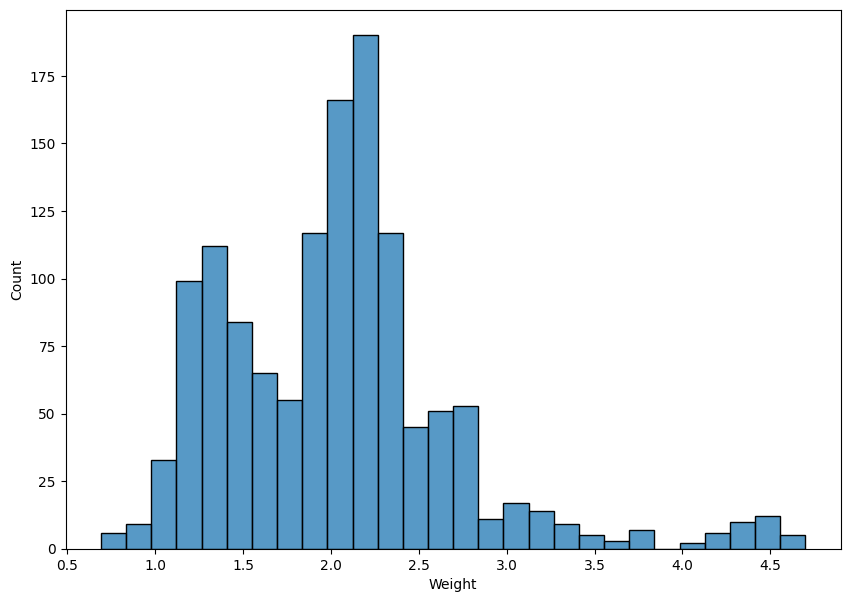

In [62]:
plt.figure(figsize=(10,7))
sns.histplot(df['Weight'])
plt.show()

### Weight vs Price

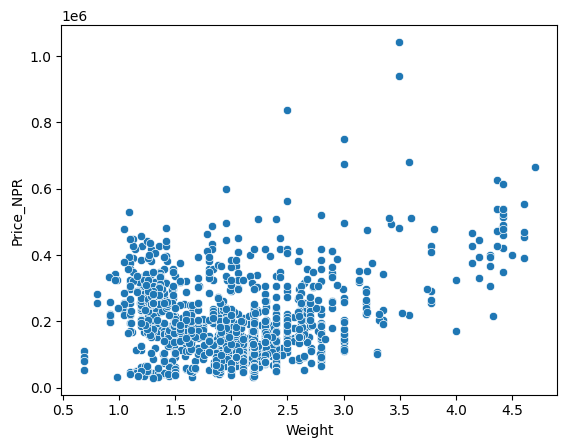

In [65]:
sns.scatterplot(x= df['Weight'],y = df['Price_NPR'])
plt.show()

### Price

In [63]:

df.corr()['Price_NPR']

laptop_ID             0.067830
Ram                   0.743007
OpSys                 0.288911
Weight                0.210370
Price_NPR             1.000000
Acer                 -0.208349
Apple                 0.080688
Asus                 -0.010376
Chuwi                -0.055646
Dell                  0.048509
Fujitsu              -0.027135
Google                0.038086
HP                   -0.041291
Huawei                0.016851
LG                    0.067053
Lenovo               -0.029007
MSI                   0.180100
Mediacom             -0.087161
Microsoft             0.047562
Razer                 0.233756
Samsung               0.034584
Toshiba               0.040339
Vero                 -0.071972
Xiaomi                0.000776
2 in 1 Convertible    0.072675
Gaming                0.375789
Netbook              -0.097572
Notebook             -0.549248
Ultrabook             0.255658
Workstation           0.249752
Touchscreen           0.191226
IPS                   0.252208
PPI     

C:\Users\rajee\AppData\Local\Temp\ipykernel_13808\1676452381.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_price.index, y=corr_price.values, palette='coolwarm')


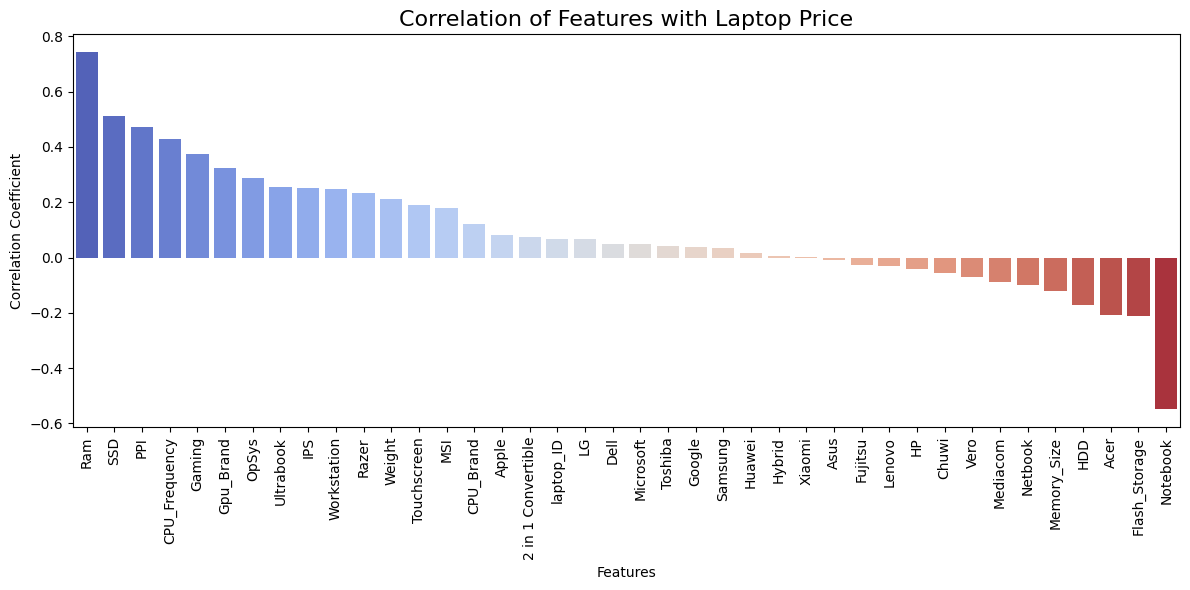

In [64]:
# Get correlations with Price_NPR
corr_price = df.corr()['Price_NPR'].sort_values(ascending=False)

# Drop Price_NPR itself
corr_price = corr_price.drop('Price_NPR')

# Plot the correlations
plt.figure(figsize=(12,6))
sns.barplot(x=corr_price.index, y=corr_price.values, palette='coolwarm')
plt.xticks(rotation=90)
plt.title("Correlation of Features with Laptop Price", fontsize=16)
plt.ylabel("Correlation Coefficient")
plt.xlabel("Features")
plt.tight_layout()
plt.show()

### Visualizing correlations after feature engineering
### to see how the newly created features relate to Price_NPR

### Step 05: Correlation Heatmap

In [65]:
corr = df.corr()

### Plotting the Heatmap

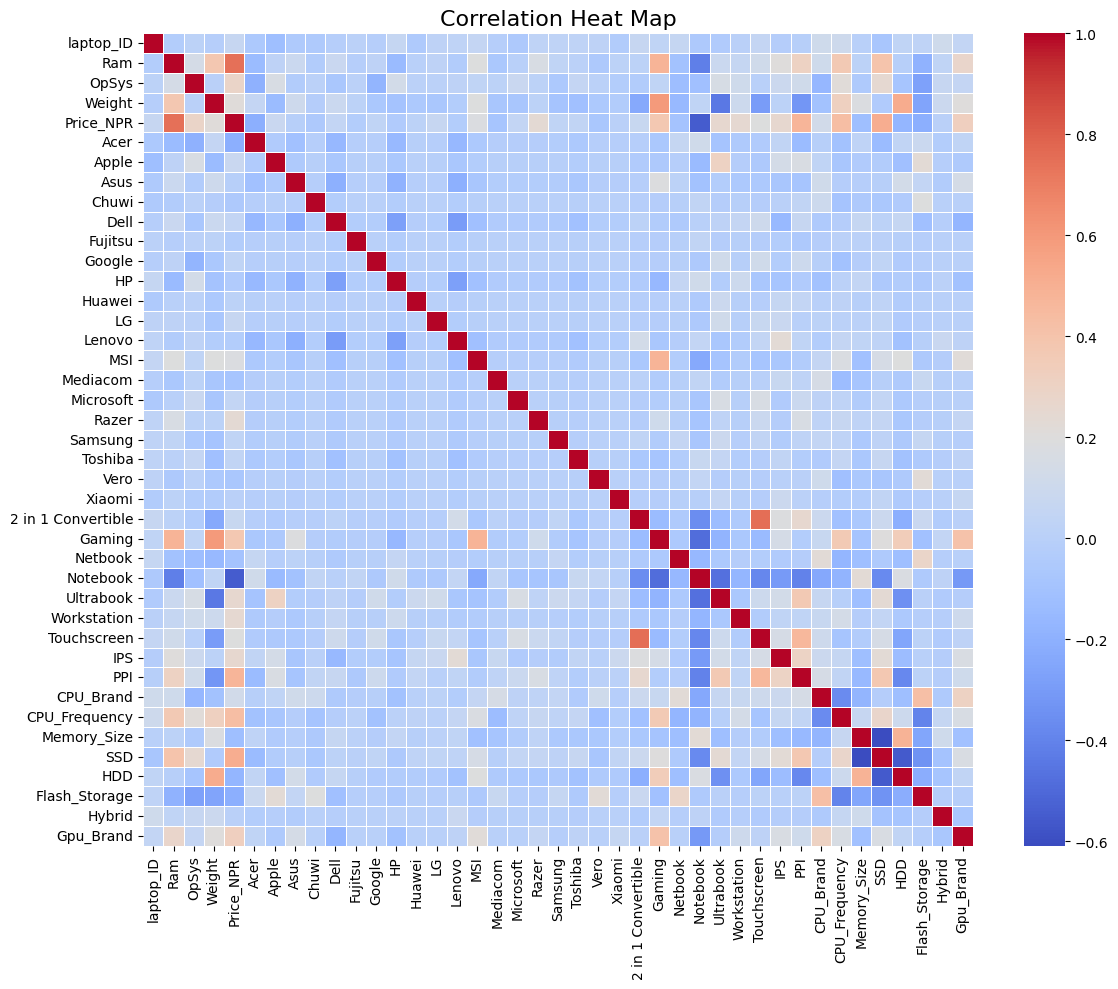

In [66]:
### Correlation Heat Map
numeric_df = df.select_dtypes(include=['int64', 'float64', 'int32'])
corr = numeric_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', annot=False, linewidths=0.5)
plt.title("Correlation Heat Map", fontsize=16)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [67]:
df.head()

,laptop_ID,Ram,OpSys,Weight,Price_NPR,Acer,Apple,Asus,Chuwi,Dell,...,IPS,PPI,CPU_Brand,CPU_Frequency,Memory_Size,SSD,HDD,Flash_Storage,Hybrid,Gpu_Brand
0,1,8,8,1.37,178178.77,0,1,0,0,0,...,1,226.983005,2,2.3,128,1,0,0,0,2
1,2,8,8,1.34,119559.02,0,1,0,0,0,...,0,127.677940,2,1.8,128,0,0,1,0,2
2,3,8,4,1.86,76475.00,0,0,0,0,0,...,0,141.211998,2,2.5,256,1,0,0,0,2
3,4,16,8,1.83,337480.85,0,1,0,0,0,...,1,220.534624,3,2.7,512,1,0,0,0,0
4,5,8,8,1.37,239878.80,0,1,0,0,0,...,1,226.983005,2,3.1,256,1,0,0,0,2


In [68]:
df.iloc[3]  

laptop_ID                  4.000000
Ram                       16.000000
OpSys                      8.000000
Weight                     1.830000
Price_NPR             337480.850000
Acer                       0.000000
Apple                      1.000000
Asus                       0.000000
Chuwi                      0.000000
Dell                       0.000000
Fujitsu                    0.000000
Google                     0.000000
HP                         0.000000
Huawei                     0.000000
LG                         0.000000
Lenovo                     0.000000
MSI                        0.000000
Mediacom                   0.000000
Microsoft                  0.000000
Razer                      0.000000
Samsung                    0.000000
Toshiba                    0.000000
Vero                       0.000000
Xiaomi                     0.000000
2 in 1 Convertible         0.000000
Gaming                     0.000000
Netbook                    0.000000
Notebook                   0

In [69]:
df.OpSys.value_counts()

OpSys
5    1072
4      66
2      62
7      45
1      27
8      13
3       8
6       8
0       2
Name: count, dtype: int64

### Step 06:  Preparing for data modeling

In [70]:
from sklearn.model_selection import train_test_split

In [71]:
X = df.drop(['Price_NPR','laptop_ID'], axis=1)
y = df['Price_NPR']
print(X.shape)
print(y.shape)

(1303, 39)
(1303,)


In [72]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Model Training

In [73]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

## Linear Regression

In [74]:
lr = LinearRegression()
lr_model = lr.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("Linear Regression Results:")
print("R2 Score:", r2)
print(f"Model Accuracy: {r2*100:.2f}%")
print("Mean Squared Error:", mse)

Linear Regression Results:
R2 Score: 0.7474233816470319
Model Accuracy: 74.74%
Mean Squared Error: 2269328248.7515736


## Random Forest

In [75]:

rf = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model = rf.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)

print("Random Forest Regression Results:")
print("R2 Score:", r2_rf)
print(f"Model Accuracy: {r2_rf*100:.2f}%")
print("Mean Squared Error:", mse_rf)

Random Forest Regression Results:
R2 Score: 0.81960151702366
Model Accuracy: 81.96%
Mean Squared Error: 1620828468.2869468


### Step 7: Model Evaluation

I tested **Linear Regression** and **Random Forest Regression** for predicting laptop prices.

- **Linear Regression** achieved an R² score of 74.7%
- **Random Forest Regression** achieved an R² score of 82.1%

Since **Random Forest Regression** has higher accuracy and can capture complex relationships between features. I found that it will be the best choice for predicting laptop prices in this dataset.

### Step 08: Dumping the Model

In [76]:
import joblib
joblib.dump(rf_model,"laptop_price_prediction_model.pkl")
print("Model dumped successfully!")

Model dumped successfully!


### Displaying the number of columns from the dataset

In [77]:
print(X.columns)

Index(['Ram', 'OpSys', 'Weight', 'Acer', 'Apple', 'Asus', 'Chuwi', 'Dell',
       'Fujitsu', 'Google', 'HP', 'Huawei', 'LG', 'Lenovo', 'MSI', 'Mediacom',
       'Microsoft', 'Razer', 'Samsung', 'Toshiba', 'Vero', 'Xiaomi',
       '2 in 1 Convertible', 'Gaming', 'Netbook', 'Notebook', 'Ultrabook',
       'Workstation', 'Touchscreen', 'IPS', 'PPI', 'CPU_Brand',
       'CPU_Frequency', 'Memory_Size', 'SSD', 'HDD', 'Flash_Storage', 'Hybrid',
       'Gpu_Brand'],
      dtype='object')


In [78]:
df.head()

,laptop_ID,Ram,OpSys,Weight,Price_NPR,Acer,Apple,Asus,Chuwi,Dell,...,IPS,PPI,CPU_Brand,CPU_Frequency,Memory_Size,SSD,HDD,Flash_Storage,Hybrid,Gpu_Brand
0,1,8,8,1.37,178178.77,0,1,0,0,0,...,1,226.983005,2,2.3,128,1,0,0,0,2
1,2,8,8,1.34,119559.02,0,1,0,0,0,...,0,127.677940,2,1.8,128,0,0,1,0,2
2,3,8,4,1.86,76475.00,0,0,0,0,0,...,0,141.211998,2,2.5,256,1,0,0,0,2
3,4,16,8,1.83,337480.85,0,1,0,0,0,...,1,220.534624,3,2.7,512,1,0,0,0,0
4,5,8,8,1.37,239878.80,0,1,0,0,0,...,1,226.983005,2,3.1,256,1,0,0,0,2


### Visualization using Scatter Plot

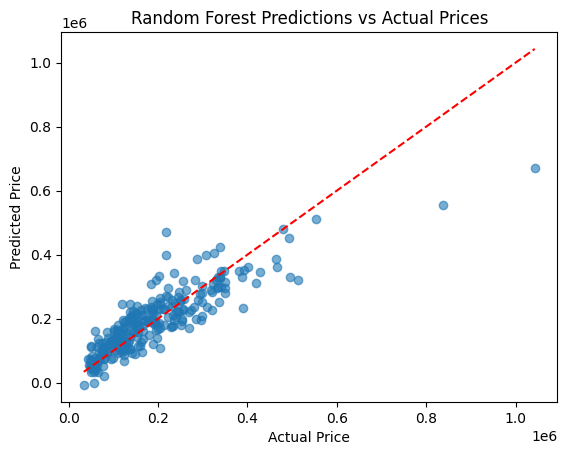

In [73]:
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # diagonal
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest Predictions vs Actual Prices")
plt.show()